In [45]:
import importlib
import src.model

importlib.reload(src.model)

<module 'src.model' from 'D:\\kuliah\\sem 4\\sistem rekomendasi\\rekomendasi-wisata\\src\\model.py'>

In [26]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from src.data_loader import load_data
from src.preprocessing import preprocess_data
from src.feature_engineering import create_content_feature
from src.model import build_model
from src.model import get_recommendations
from src.evaluation import precision_at_k

In [27]:
df = load_data()

print(df.shape)

df.head()

(437, 11)


,Place_Id,Place_Name,Description,Category,City,Price,Rating,Time_Minutes,Coordinate,Lat,Long
0,1,Monumen Nasional,Monumen Nasional atau yang populer disingkat d...,Budaya,Jakarta,20000,4.6,15.0,"{'lat': -6.1753924, 'lng': 106.8271528}",-6.175392,106.827153
1,2,Kota Tua,"Kota tua di Jakarta, yang juga bernama Kota Tu...",Budaya,Jakarta,0,4.6,90.0,"{'lat': -6.137644799999999, 'lng': 106.8171245}",-6.137645,106.817125
2,3,Dunia Fantasi,Dunia Fantasi atau disebut juga Dufan adalah t...,Taman Hiburan,Jakarta,270000,4.6,360.0,"{'lat': -6.125312399999999, 'lng': 106.8335377}",-6.125312,106.833538
3,4,Taman Mini Indonesia Indah (TMII),Taman Mini Indonesia Indah merupakan suatu kaw...,Taman Hiburan,Jakarta,10000,4.5,NaN,"{'lat': -6.302445899999999, 'lng': 106.8951559}",-6.302446,106.895156
4,5,Atlantis Water Adventure,Atlantis Water Adventure atau dikenal dengan A...,Taman Hiburan,Jakarta,94000,4.5,60.0,"{'lat': -6.12419, 'lng': 106.839134}",-6.124190,106.839134


In [28]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 437 entries, 0 to 436
Data columns (total 11 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Place_Id      437 non-null    int64  
 1   Place_Name    437 non-null    object 
 2   Description   437 non-null    object 
 3   Category      437 non-null    object 
 4   City          437 non-null    object 
 5   Price         437 non-null    int64  
 6   Rating        437 non-null    float64
 7   Time_Minutes  205 non-null    float64
 8   Coordinate    437 non-null    object 
 9   Lat           437 non-null    float64
 10  Long          437 non-null    float64
dtypes: float64(4), int64(2), object(5)
memory usage: 37.7+ KB


In [29]:
df.describe()

,Place_Id,Price,Rating,Time_Minutes,Lat,Long
count,437.000000,437.000000,437.000000,205.000000,437.000000,437.000000
mean,219.000000,24652.173913,4.442792,82.609756,-7.095438,109.160142
std,126.295289,66446.374709,0.208587,52.872339,0.727241,1.962848
min,1.000000,0.000000,3.400000,10.000000,-8.197894,103.931398
25%,110.000000,0.000000,4.300000,45.000000,-7.749590,107.578369
50%,219.000000,5000.000000,4.500000,60.000000,-7.020524,110.237468
75%,328.000000,20000.000000,4.600000,120.000000,-6.829411,110.431869
max,437.000000,900000.000000,5.000000,360.000000,1.078880,112.821662


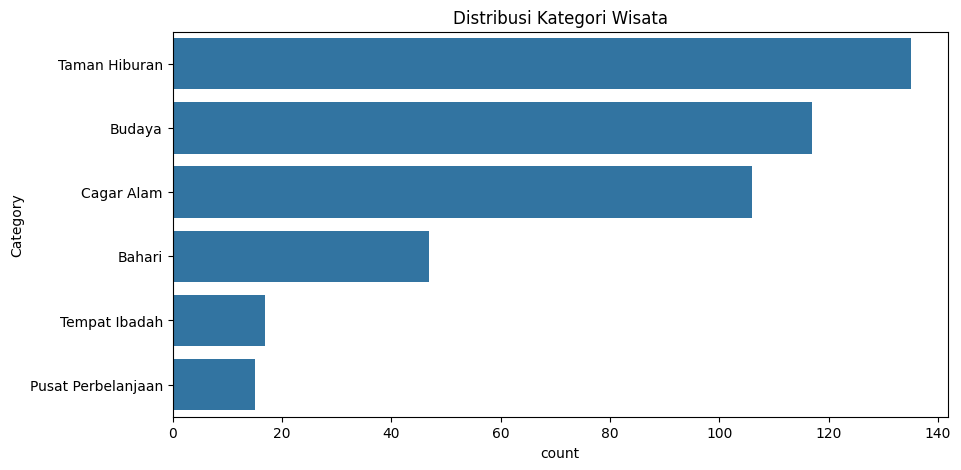

In [30]:
plt.figure(figsize=(10,5))

sns.countplot(
    data=df,
    y="Category",
    order=df["Category"].value_counts().index
)

plt.title("Distribusi Kategori Wisata")
plt.show()

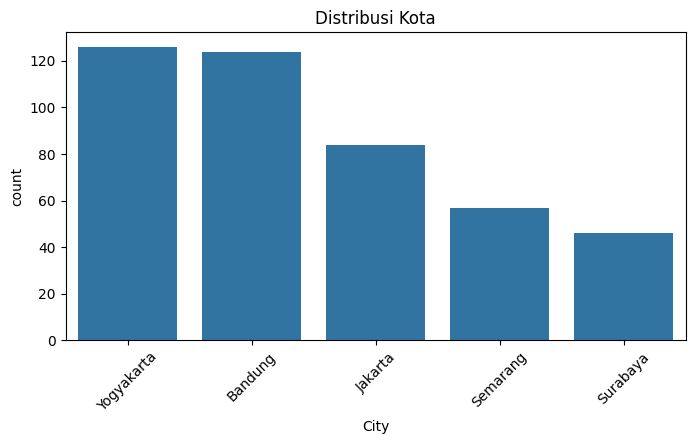

In [31]:
plt.figure(figsize=(8,4))

sns.countplot(
    data=df,
    x="City",
    order=df["City"].value_counts().index
)

plt.title("Distribusi Kota")
plt.xticks(rotation=45)
plt.show()

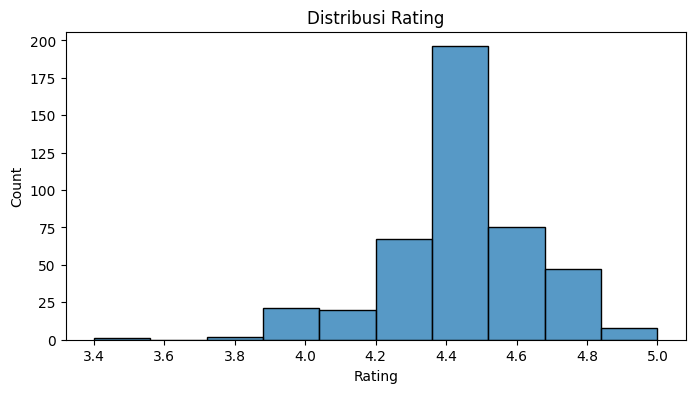

In [32]:
plt.figure(figsize=(8,4))

sns.histplot(
    df["Rating"],
    bins=10
)

plt.title("Distribusi Rating")
plt.show()

In [33]:
df = preprocess_data(df)

df.head()

,Place_Id,Place_Name,Description,Category,City,Price,Rating,Time_Minutes,Coordinate,Lat,Long
0,1,monumen nasional,monumen nasional atau yang populer disingkat d...,budaya,jakarta,20000,4.6,15.0,"{'lat': -6.1753924, 'lng': 106.8271528}",-6.175392,106.827153
1,2,kota tua,"kota tua di jakarta, yang juga bernama kota tu...",budaya,jakarta,0,4.6,90.0,"{'lat': -6.137644799999999, 'lng': 106.8171245}",-6.137645,106.817125
2,3,dunia fantasi,dunia fantasi atau disebut juga dufan adalah t...,taman hiburan,jakarta,270000,4.6,360.0,"{'lat': -6.125312399999999, 'lng': 106.8335377}",-6.125312,106.833538
3,4,taman mini indonesia indah (tmii),taman mini indonesia indah merupakan suatu kaw...,taman hiburan,jakarta,10000,4.5,NaN,"{'lat': -6.302445899999999, 'lng': 106.8951559}",-6.302446,106.895156
4,5,atlantis water adventure,atlantis water adventure atau dikenal dengan a...,taman hiburan,jakarta,94000,4.5,60.0,"{'lat': -6.12419, 'lng': 106.839134}",-6.124190,106.839134


In [34]:
df = create_content_feature(df)

df[
    [
        "Place_Name",
        "content"
    ]
].head()

,Place_Name,content
0,monumen nasional,budaya jakarta monumen nasional atau yang popu...
1,kota tua,"budaya jakarta kota tua di jakarta, yang juga ..."
2,dunia fantasi,taman hiburan jakarta dunia fantasi atau diseb...
3,taman mini indonesia indah (tmii),taman hiburan jakarta taman mini indonesia ind...
4,atlantis water adventure,taman hiburan jakarta atlantis water adventure...


In [35]:
cosine_sim = build_model(df)

print(type(cosine_sim))

print(cosine_sim.shape)

<class 'numpy.ndarray'>
(437, 437)


In [36]:
get_recommendations(
    "monumen nasional",
    df,
    cosine_sim,
    top_n=5
)

,Place_Name,Category,City,Rating
43,monumen selamat datang,budaya,jakarta,4.7
256,monumen bandung lautan api,budaya,bandung,4.3
258,monumen perjuangan rakyat jawa barat,budaya,bandung,4.5
427,monumen bambu runcing surabaya,budaya,surabaya,4.6
380,tugu muda semarang,budaya,semarang,4.7


In [37]:
target = "monumen nasional"

actual_category = df[
    df["Place_Name"] == target
]["Category"].values[0]

In [38]:
recs = get_recommendations(
    target,
    df,
    cosine_sim,
    top_n=5
)

In [39]:
precision = precision_at_k(
    recs,
    actual_category
)

print(
    f"Precision@5 = {precision:.2f}"
)

Precision@5 = 1.00
